# 2-dimensional Simulation

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
import math

In [ ]:
torch.manual_seed(27)

In [ ]:
# Parameters
n = 50        # number of data points
d = 2         # dimension
device = 'cpu'

## Construction of datasets

In [ ]:
# dataset 0: equidistant and not parallel
if n % 2 == 0: # avoids parallel points
  n = n+1
print('We cosider', n, 'datapoints.')
angles = torch.linspace(0, 2*np.pi, n+1)[:-1]
X_0 = torch.stack([torch.cos(angles), torch.sin(angles)], dim=1)
angles_0 = torch.atan2(X_0[:, 1], X_0[:, 0])
Y_0 = torch.sin(4*angles_0)

# dataset A: no parallelity
X_A = torch.randn(n, d, device=device)
normX_A = X_A / torch.norm(X_A, dim=1, keepdim=True)
angles_A = torch.atan2(normX_A[:, 1], normX_A[:, 0])
Y_A = torch.sin(4*angles_A)


# dataset B: includes some parallel vectors
mu = torch.zeros(d)
cov = torch.tensor([1.0, 3.0])

X_B = torch.normal(mu.repeat(n, 1), cov.repeat(n, 1))
normX_B = X_B / torch.norm(X_B, dim=1, keepdim=True)
angles_B = torch.atan2(normX_B[:, 1], normX_B[:, 0])
Y_B = torch.sin(4*angles_B)


# dataset C: dataset B with added parallel vectors
X_C = X_B
for i in range(round(n/2)):
  X_C = torch.cat([X_C, X_C[i].unsqueeze(0)])
normX_C = X_C / torch.norm(X_C, dim=1, keepdim=True)
angles_C = torch.atan2(normX_C[:, 1], normX_C[:, 0])
Y_C = torch.sin(4*angles_C)


# dataset D: lots of parallel vectors
mu_2 = torch.zeros(d)
cov_2 = torch.tensor([1.0, 50.0])

X_D = torch.normal(mu_2.repeat(n, 1), cov_2.repeat(n, 1))
normX_D = X_D / torch.norm(X_D, dim=1, keepdim=True)
angles_D = torch.atan2(normX_D[:, 1], normX_D[:, 0])
Y_D = torch.sin(4*angles_D)

We cosider 51 datapoints.


In [ ]:
# function that checks for parallelity within a tolerance

def check_parallelity(X, Y, name, delete=True, Xmod=torch.empty(n), TOL=1e-7):
  min = 0
  count = 0
  initial_shape = X.shape[0]
  i = 0
  while i < X.shape[0]:
    j = i + 1
    while j < X.shape[0]:
      if torch.abs(torch.dot(X[i], X[j])) >= 1 - TOL:
        if delete == True:
          X = torch.cat([X[0:j], X[j+1:]])
          Y = torch.cat([Y[0:j], Y[j+1:]])
          Xmod = torch.cat([Xmod[0:j], Xmod[j+1:]])
          count = count + 1
        else:
          count = count + 1
      elif (torch.abs(torch.dot(X[i], X[j]))) > min:
        min = torch.abs(torch.dot(X[i], X[j]))
      j = j + 1
    i = i + 1

  if delete == True:
    print('Deleted', initial_shape - X.shape[0], 'datapoints from set', name, 'to avoid parallel datapoints.')
  else:
    print('Set', name, 'includes', count, 'pairs of parallel datapoints.')

  return X, Y, min, Xmod

In [ ]:
# check datasets for parallel points

X_0, Y_0, min0, _ = check_parallelity(X_0, Y_0, 'X_0')
normX_A, Y_A, minA, X_A = check_parallelity(normX_A, Y_A, 'X_A', True, X_A)
normX_B, Y_B, minB, _ = check_parallelity(normX_B, Y_B, 'X_B', False)
normX_C, Y_C, minC, _ = check_parallelity(normX_C, Y_C, 'X_C', False)
normX_D, Y_D, minD, _ = check_parallelity(normX_D, Y_D, 'X_D', False)

Deleted 0 datapoints from set X_0 to avoid parallel datapoints.
Deleted 0 datapoints from set X_A to avoid parallel datapoints.
Set X_B includes 1 pairs of parallel datapoints.
Set X_C includes 28 pairs of parallel datapoints.
Set X_D includes 14 pairs of parallel datapoints.


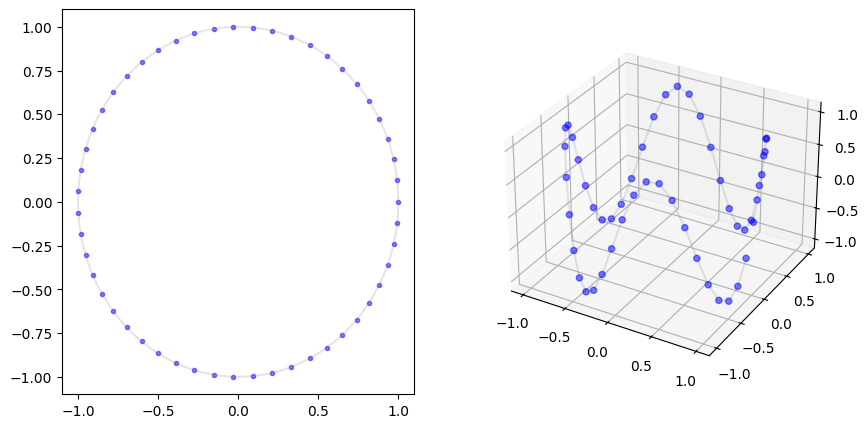

In [ ]:
# plot dataset X_0

fig = plt.figure(figsize=(10, 5))

theta = np.linspace(0, 2 * np.pi, 150)
x = np.cos(theta)
y = np.sin(theta)

ax0 = fig.add_subplot(1, 2, 1)
ax0.plot(X_0[:, 0], X_0[:, 1], '.', color='blue', alpha = 0.5)
ax0.plot(x, y, alpha = 0.2, color = 'gray')

ax1 = fig.add_subplot(1, 2, 2, projection='3d')
ax1.scatter(X_0[:, 0], X_0[:, 1], Y_0, color='blue', alpha = 0.5)
ax1.plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha = 0.2)

#fig.suptitle('Dataset X_0')
plt.show()

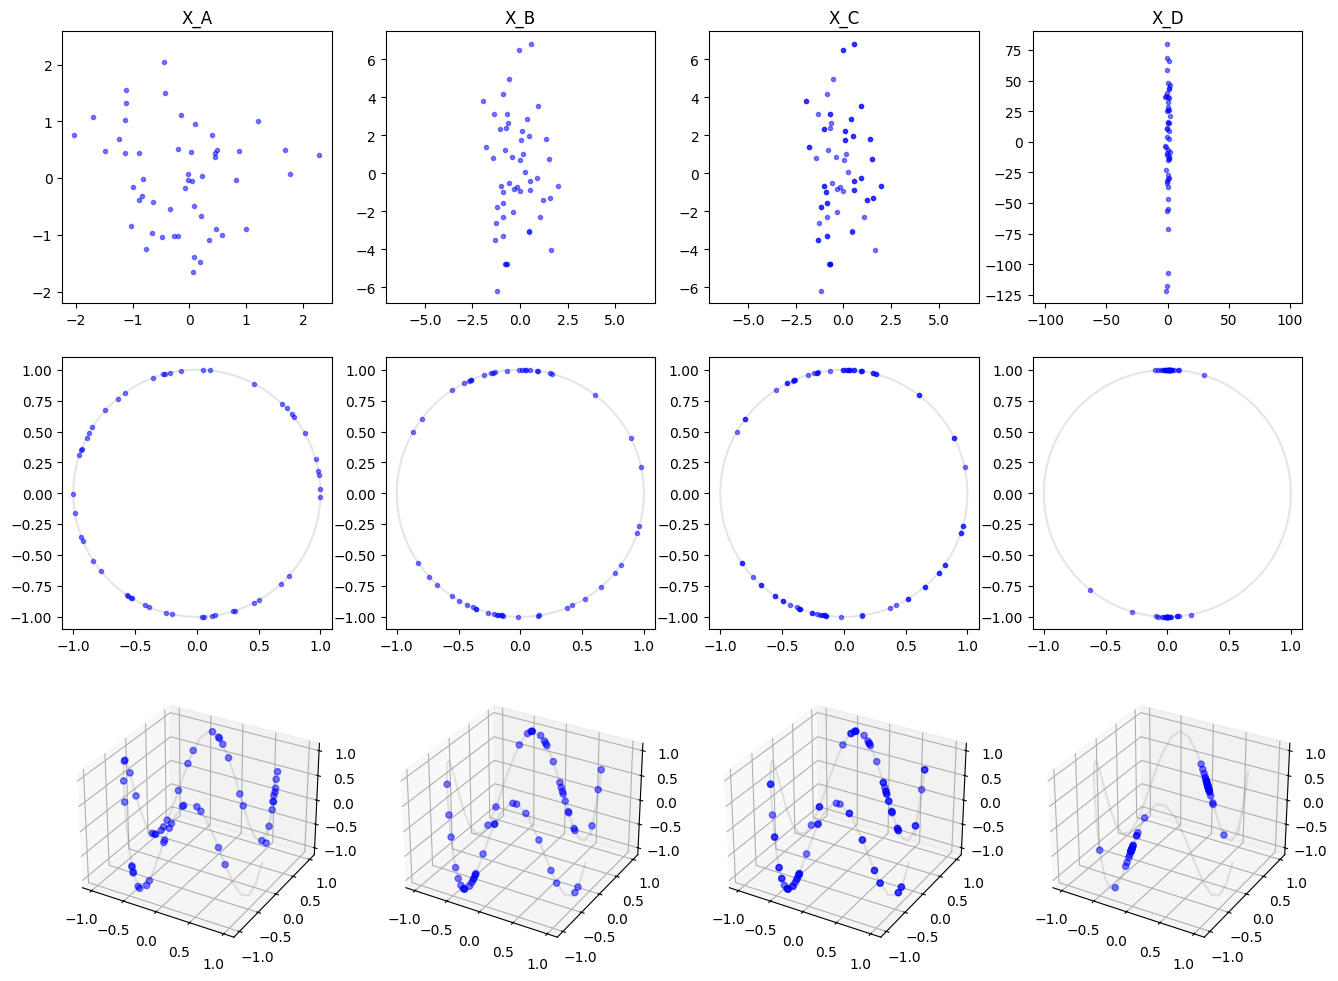

In [ ]:
# plot datasets X_A, X_B, X_C, X_D

fig, axs = plt.subplots(3, 4, figsize=(16, 12))

# plot distribution of datapoints
axs[0][0].plot(X_A[:, 0], X_A[:, 1], '.', color='blue', alpha = 0.5)
axs[0][0].set_title('X_A')
axs[0][0].axis("equal")

axs[0][1].plot(X_B[:, 0], X_B[:, 1], '.', color='blue', alpha = 0.5)
axs[0][1].set_title('X_B')
axs[0][1].axis("equal")

axs[0][2].plot(X_C[:, 0], X_C[:, 1], '.', color='blue', alpha = 0.5)
axs[0][2].set_title('X_C')
axs[0][2].axis("equal")

axs[0][3].plot(X_D[:, 0], X_D[:, 1], '.', color='blue', alpha = 0.5)
axs[0][3].set_title('X_D')
axs[0][3].axis("equal")


# plot normalized data points
axs[1][0].plot(x, y, alpha = 0.2, color = 'gray')
axs[1][1].plot(x, y, alpha = 0.2, color = 'gray')
axs[1][2].plot(x, y, alpha = 0.2, color = 'gray')
axs[1][3].plot(x, y, alpha = 0.2, color = 'gray')

axs[1][0].plot(normX_A[:, 0], normX_A[:, 1], '.', color='blue', alpha = 0.5)
#axs[1][0].set_title('normalized X_A')
axs[1][0].set_xlim([-1, 1])
axs[1][0].axis("equal")

axs[1][1].plot(normX_B[:, 0], normX_B[:, 1], '.', color='blue', alpha = 0.5)
#axs[1][1].set_title('normalized X_B')
axs[1][1].set_ylim([-1, 1])
axs[1][1].axis("equal")

axs[1][2].plot(normX_C[:, 0], normX_C[:, 1], '.', color='blue', alpha = 0.5)
#axs[1][2].set_title('normalized X_C')
axs[1][2].set_xlim([-1, 1])
axs[1][2].axis("equal")

axs[1][3].plot(normX_D[:, 0], normX_D[:, 1], '.', color='blue', alpha = 0.5)
#axs[1][3].set_title('normalized X_D')
axs[1][3].set_xlim([-1, 1])
axs[1][3].axis("equal")

# plot 3D view
axs[2][0].remove()
axs[2][0] = fig.add_subplot(3, 4, 9, projection='3d')
axs[2][0].scatter(normX_A[:, 0], normX_A[:, 1], Y_A, color='blue', alpha=0.5)
axs[2][0].plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)
#axs[2][0].set_title('3D View')

axs[2][1].remove()
axs[2][1] = fig.add_subplot(3, 4, 10, projection='3d')
axs[2][1].scatter(normX_B[:, 0], normX_B[:, 1], Y_B, color='blue', alpha=0.5)
axs[2][1].plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)
#axs[2][1].set_title('3D View')

axs[2][2].remove()
axs[2][2] = fig.add_subplot(3, 4, 11, projection='3d')
axs[2][2].scatter(normX_C[:, 0], normX_C[:, 1], Y_C, color='blue', alpha=0.5)
axs[2][2].plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)
#axs[2][2].set_title('3D View')

axs[2][3].remove()
axs[2][3] = fig.add_subplot(3, 4, 12, projection='3d')
axs[2][3].scatter(normX_D[:, 0], normX_D[:, 1], Y_D, color='blue', alpha=0.5)
axs[2][3].plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)
#axs[2][3].set_title('3D View')

plt.show()

## Gram matrix and its least eigenvalue

In [ ]:
# compute the Gram matrix of a dataset X

def gram_matrix(X):
  H = torch.zeros((X.shape[0], X.shape[0]))

  for i in range(X.shape[0]):
    for j in range(i, X.shape[0]):
      rho = torch.clamp(torch.dot(X[i], X[j]), -1.0, 1.0) # ensures rho \in [-1, 1]
      H[i, j] = torch.clamp(torch.dot(X[i], X[j]), -1.0, 1.0)*(0.25 + (torch.arcsin(rho) / (2 * math.pi)))
      if i != j:
        H[j, i] = H[i, j]

  return H

In [ ]:
# returns the least eigenvalue of a matrix H

def compute_lambda_min(H):
    eigenvalues = torch.linalg.eigvalsh(H)   # eigenvalues are returned in ascending order
    return eigenvalues[0]

In [ ]:
H_0 = gram_matrix(X_0)
H_A = gram_matrix(normX_A)
H_B = gram_matrix(normX_B)
H_C = gram_matrix(normX_C)
H_D = gram_matrix(normX_D)

lambda_0 = compute_lambda_min(H_0)
lambda_A = compute_lambda_min(H_A)
lambda_B = compute_lambda_min(H_B)
lambda_C = compute_lambda_min(H_C)
lambda_D = compute_lambda_min(H_D)

print(lambda_0)
print(lambda_A)
print(lambda_B)
print(lambda_C)
print(lambda_D)

tensor(0.0049)
tensor(0.0009)
tensor(0.0001)
tensor(-8.0376e-07)
tensor(-2.8498e-05)


In [ ]:
def gram_matrix_of_k(X, W, a, m):
  H = torch.zeros(X.shape[0], X.shape[0])

  preActivation = X @ W # Shape (n, m)

  for i in range(X.shape[0]):
    for j in range(i, X.shape[0]):

      indicator = (preActivation[i, :] >= 0) & (preActivation[j, :] >= 0)

      H[i, j] = (1 / m) * torch.clamp(torch.dot(X[i], X[j]), -1.0, 1.0) * (torch.square(a) * indicator.float()).sum()

      if i != j:
        H[j, i] = H[i, j]

  return H

In [ ]:
def norm(H):
  return torch.sum(H**2)

## Neural Network with one hidden layer and ReLU activation

In [ ]:
class NeuralNetwork(torch.nn.Module):
    def __init__(self, d, m):
        super().__init__()
        self.W = torch.nn.Parameter(torch.randn(d, m, device=device))
        self.a = torch.nn.Parameter((-1)**torch.bernoulli(1/2 * torch.ones(m, device=device)))
        self.m = m

    def forward(self, X):
        Z = torch.relu(X @ self.W)
        U = (Z * self.a).sum(dim=1) / math.sqrt(self.m)
        return U

## Choice of Step Size

In [ ]:
'''m = 1000
eta = [0.0001, 0.001, 0.01, 0.1, 1, 10]
epochs = 20000'''

'm = 1000\neta = [0.0001, 0.001, 0.01, 0.1, 1, 10]\nepochs = 20000'

In [ ]:
'''# plots for dataset X_0

plotY_0 = []

for i in range(len(eta)):
  plotX_0 = []

  print(f"Training on dataset X_0 for eta = {eta[i]}")
  model = NeuralNetwork(d, m)
  optimizer = torch.optim.SGD([model.W, model.a], lr=eta[i])

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(X_0)
    loss = 0.5 * torch.mean((U - Y_0) ** 2)
    loss.backward()
    optimizer.step()

    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      plotY_0.append(loss.item())
      plotX_0.append(epoch+1)'''

'# plots for dataset X_0\n\nplotY_0 = []\n\nfor i in range(len(eta)):\n  plotX_0 = []\n\n  print(f"Training on dataset X_0 for eta = {eta[i]}")\n  model = NeuralNetwork(d, m)\n  optimizer = torch.optim.SGD([model.W, model.a], lr=eta[i])\n\n  for epoch in range(epochs):\n    optimizer.zero_grad()\n    U = model(X_0)\n    loss = 0.5 * torch.mean((U - Y_0) ** 2)\n    loss.backward()\n    optimizer.step()\n\n    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):\n      print(\'Epoch\', epoch+1, \'Loss:\', np.round(loss.item(), decimals=10))\n      plotY_0.append(loss.item())\n      plotX_0.append(epoch+1)'

In [ ]:
'''fig = plt.figure(figsize=(5,5))

for i in range(len(eta)):

  plt.loglog(plotX_0, plotY_0[i*len(plotX_0):(i+1)*len(plotX_0)], label = f'eta = {eta[i]}')

plt.title('X_0')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()'''

"fig = plt.figure(figsize=(5,5))\n\nfor i in range(len(eta)):\n\n  plt.loglog(plotX_0, plotY_0[i*len(plotX_0):(i+1)*len(plotX_0)], label = f'eta = {eta[i]}')\n\nplt.title('X_0')\nplt.xlabel('Epoch')\nplt.ylabel('Loss')\nplt.legend()\n\nplt.show()"

In [ ]:
'''# plots for dataset X_A

plotY_A = []

for i in range(len(eta)):
  plotX_A = []

  print(f"Training on dataset X_A for eta = {eta[i]}")
  model = NeuralNetwork(d, m)
  optimizer = torch.optim.SGD([model.W, model.a], lr=eta[i])

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(normX_A)
    loss = 0.5 * torch.mean((U - Y_A) ** 2)
    loss.backward()
    optimizer.step()

    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      plotY_A.append(loss.item())
      plotX_A.append(epoch+1)'''

'# plots for dataset X_A\n\nplotY_A = []\n\nfor i in range(len(eta)):\n  plotX_A = []\n\n  print(f"Training on dataset X_A for eta = {eta[i]}")\n  model = NeuralNetwork(d, m)\n  optimizer = torch.optim.SGD([model.W, model.a], lr=eta[i])\n\n  for epoch in range(epochs):\n    optimizer.zero_grad()\n    U = model(normX_A)\n    loss = 0.5 * torch.mean((U - Y_A) ** 2)\n    loss.backward()\n    optimizer.step()\n\n    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):\n      print(\'Epoch\', epoch+1, \'Loss:\', np.round(loss.item(), decimals=10))\n      plotY_A.append(loss.item())\n      plotX_A.append(epoch+1)'

In [ ]:
'''fig = plt.figure(figsize=(5,5))

for i in range(len(eta)):

  plt.loglog(plotX_A, plotY_A[i*len(plotX_A):(i+1)*len(plotX_A)], label = f'eta = {eta[i]}')

plt.title('X_A')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()'''

"fig = plt.figure(figsize=(5,5))\n\nfor i in range(len(eta)):\n\n  plt.loglog(plotX_A, plotY_A[i*len(plotX_A):(i+1)*len(plotX_A)], label = f'eta = {eta[i]}')\n\nplt.title('X_A')\nplt.xlabel('Epoch')\nplt.ylabel('Loss')\nplt.legend()\n\nplt.show()"

In [ ]:
'''# plots for dataset X_B

plotY_B = []

for i in range(len(eta)):
  plotX_B = []

  print(f"Training on dataset X_B for eta = {eta[i]}")
  model = NeuralNetwork(d, m)
  optimizer = torch.optim.SGD([model.W, model.a], lr=eta[i])

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(normX_B)
    loss = 0.5 * torch.mean((U - Y_B) ** 2)
    loss.backward()
    optimizer.step()

    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      plotY_B.append(loss.item())
      plotX_B.append(epoch+1)'''

'# plots for dataset X_B\n\nplotY_B = []\n\nfor i in range(len(eta)):\n  plotX_B = []\n\n  print(f"Training on dataset X_B for eta = {eta[i]}")\n  model = NeuralNetwork(d, m)\n  optimizer = torch.optim.SGD([model.W, model.a], lr=eta[i])\n\n  for epoch in range(epochs):\n    optimizer.zero_grad()\n    U = model(normX_B)\n    loss = 0.5 * torch.mean((U - Y_B) ** 2)\n    loss.backward()\n    optimizer.step()\n\n    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):\n      print(\'Epoch\', epoch+1, \'Loss:\', np.round(loss.item(), decimals=10))\n      plotY_B.append(loss.item())\n      plotX_B.append(epoch+1)'

In [ ]:
'''fig = plt.figure(figsize=(5,5))

for i in range(len(eta)):

  plt.loglog(plotX_B, plotY_B[i*len(plotX_B):(i+1)*len(plotX_B)], label = f'eta = {eta[i]}')

plt.title('X_B')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()'''

"fig = plt.figure(figsize=(5,5))\n\nfor i in range(len(eta)):\n\n  plt.loglog(plotX_B, plotY_B[i*len(plotX_B):(i+1)*len(plotX_B)], label = f'eta = {eta[i]}')\n\nplt.title('X_B')\nplt.xlabel('Epoch')\nplt.ylabel('Loss')\nplt.legend()\n\nplt.show()"

In [ ]:
'''# plots for dataset X_C

plotY_C = []

for i in range(len(eta)):
  plotX_C = []

  print(f"Training on dataset X_C for eta = {eta[i]}")
  model = NeuralNetwork(d, m)
  optimizer = torch.optim.SGD([model.W, model.a], lr=eta[i])

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(normX_C)
    loss = 0.5 * torch.mean((U - Y_C) ** 2)
    loss.backward()
    optimizer.step()

    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      plotY_C.append(loss.item())
      plotX_C.append(epoch+1)'''

'# plots for dataset X_C\n\nplotY_C = []\n\nfor i in range(len(eta)):\n  plotX_C = []\n\n  print(f"Training on dataset X_C for eta = {eta[i]}")\n  model = NeuralNetwork(d, m)\n  optimizer = torch.optim.SGD([model.W, model.a], lr=eta[i])\n\n  for epoch in range(epochs):\n    optimizer.zero_grad()\n    U = model(normX_C)\n    loss = 0.5 * torch.mean((U - Y_C) ** 2)\n    loss.backward()\n    optimizer.step()\n\n    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):\n      print(\'Epoch\', epoch+1, \'Loss:\', np.round(loss.item(), decimals=10))\n      plotY_C.append(loss.item())\n      plotX_C.append(epoch+1)'

In [ ]:
'''fig = plt.figure(figsize=(5,5))

for i in range(len(eta)):

  plt.loglog(plotX_C, plotY_C[i*len(plotX_C):(i+1)*len(plotX_C)], label = f'eta = {eta[i]}')

plt.title('X_C')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()'''

"fig = plt.figure(figsize=(5,5))\n\nfor i in range(len(eta)):\n\n  plt.loglog(plotX_C, plotY_C[i*len(plotX_C):(i+1)*len(plotX_C)], label = f'eta = {eta[i]}')\n\nplt.title('X_C')\nplt.xlabel('Epoch')\nplt.ylabel('Loss')\nplt.legend()\n\nplt.show()"

In [ ]:
'''# plots for dataset X_D

plotY_D = []

for i in range(len(eta)):
  plotX_D = []

  print(f"Training on dataset X_D for eta = {eta[i]}")
  model = NeuralNetwork(d, m)
  optimizer = torch.optim.SGD([model.W, model.a], lr=eta[i])

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(normX_D)
    loss = 0.5 * torch.mean((U - Y_D) ** 2)
    loss.backward()
    optimizer.step()

    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      plotY_D.append(loss.item())
      plotX_D.append(epoch+1)'''

'# plots for dataset X_D\n\nplotY_D = []\n\nfor i in range(len(eta)):\n  plotX_D = []\n\n  print(f"Training on dataset X_D for eta = {eta[i]}")\n  model = NeuralNetwork(d, m)\n  optimizer = torch.optim.SGD([model.W, model.a], lr=eta[i])\n\n  for epoch in range(epochs):\n    optimizer.zero_grad()\n    U = model(normX_D)\n    loss = 0.5 * torch.mean((U - Y_D) ** 2)\n    loss.backward()\n    optimizer.step()\n\n    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):\n      print(\'Epoch\', epoch+1, \'Loss:\', np.round(loss.item(), decimals=10))\n      plotY_D.append(loss.item())\n      plotX_D.append(epoch+1)'

In [ ]:
'''fig = plt.figure(figsize=(12,5))

ax0 = fig.add_subplot(1, 2, 1)
for i in range(len(eta)):
  ax0.loglog(plotX_D, plotY_D[i*len(plotX_D):(i+1)*len(plotX_D)], label = f'eta = {eta[i]}')
ax1 = fig.add_subplot(1, 2, 2)
for i in range(len(eta)-1):
  ax1.loglog(plotX_D, plotY_D[i*len(plotX_D):(i+1)*len(plotX_D)], label = f'eta = {eta[i]}')

fig.suptitle('(X_D, Y_D)')
ax0.set_xlabel('Epoch')
ax0.set_ylabel('Loss')
ax0.legend()
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

plt.show()'''

"fig = plt.figure(figsize=(12,5))\n\nax0 = fig.add_subplot(1, 2, 1)\nfor i in range(len(eta)):\n  ax0.loglog(plotX_D, plotY_D[i*len(plotX_D):(i+1)*len(plotX_D)], label = f'eta = {eta[i]}')\nax1 = fig.add_subplot(1, 2, 2)\nfor i in range(len(eta)-1):\n  ax1.loglog(plotX_D, plotY_D[i*len(plotX_D):(i+1)*len(plotX_D)], label = f'eta = {eta[i]}')\n\nfig.suptitle('(X_D, Y_D)')\nax0.set_xlabel('Epoch')\nax0.set_ylabel('Loss')\nax0.legend()\nax1.set_xlabel('Epoch')\nax1.set_ylabel('Loss')\n\nplt.show()"

In [ ]:
'''fig = plt.figure(figsize=(12, 19))

ax0 = fig.add_subplot(3, 2, 1)
ax1 = fig.add_subplot(3, 2, 2)
ax2 = fig.add_subplot(3, 2, 3)
ax3 = fig.add_subplot(3, 2, 4)
#ax4 = fig.add_subplot(3, 2, (5, 6))

for i in range(len(eta)):
  ax0.loglog(plotX_0, plotY_0[i*len(plotX_0):(i+1)*len(plotX_0)], label = f'eta = {eta[i]}')
  ax1.loglog(plotX_A, plotY_A[i*len(plotX_A):(i+1)*len(plotX_A)], label = f'eta = {eta[i]}')
  ax2.loglog(plotX_B, plotY_B[i*len(plotX_B):(i+1)*len(plotX_B)], label = f'eta = {eta[i]}')
  ax3.loglog(plotX_C, plotY_C[i*len(plotX_C):(i+1)*len(plotX_C)], label = f'eta = {eta[i]}')
  #ax4.loglog(plotX_D, plotY_D[i*len(plotX_D):(i+1)*len(plotX_D)], label = f'eta = {eta[i]}')

ax0.set_title('(X_0, Y_0)')
ax1.set_title('(X_A, Y_A)')
ax2.set_title('(X_B, Y_B)')
ax3.set_title('(X_C, Y_C)')
#ax4.set_title('X_D')
ax0.set_xlabel('Epoch')
ax0.set_ylabel('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Loss')
#ax4.set_xlabel('Epoch')
#ax4.set_ylabel('Loss')
ax0.legend()

plt.show()'''

"fig = plt.figure(figsize=(12, 19))\n\nax0 = fig.add_subplot(3, 2, 1)\nax1 = fig.add_subplot(3, 2, 2)\nax2 = fig.add_subplot(3, 2, 3)\nax3 = fig.add_subplot(3, 2, 4)\n#ax4 = fig.add_subplot(3, 2, (5, 6))\n\nfor i in range(len(eta)):\n  ax0.loglog(plotX_0, plotY_0[i*len(plotX_0):(i+1)*len(plotX_0)], label = f'eta = {eta[i]}')\n  ax1.loglog(plotX_A, plotY_A[i*len(plotX_A):(i+1)*len(plotX_A)], label = f'eta = {eta[i]}')\n  ax2.loglog(plotX_B, plotY_B[i*len(plotX_B):(i+1)*len(plotX_B)], label = f'eta = {eta[i]}')\n  ax3.loglog(plotX_C, plotY_C[i*len(plotX_C):(i+1)*len(plotX_C)], label = f'eta = {eta[i]}')\n  #ax4.loglog(plotX_D, plotY_D[i*len(plotX_D):(i+1)*len(plotX_D)], label = f'eta = {eta[i]}')\n\nax0.set_title('(X_0, Y_0)')\nax1.set_title('(X_A, Y_A)')\nax2.set_title('(X_B, Y_B)')\nax3.set_title('(X_C, Y_C)')\n#ax4.set_title('X_D')\nax0.set_xlabel('Epoch')\nax0.set_ylabel('Loss')\nax1.set_xlabel('Epoch')\nax1.set_ylabel('Loss')\nax2.set_xlabel('Epoch')\nax2.set_ylabel('Loss')\nax3.set

## Comparison with non-normalized inputs

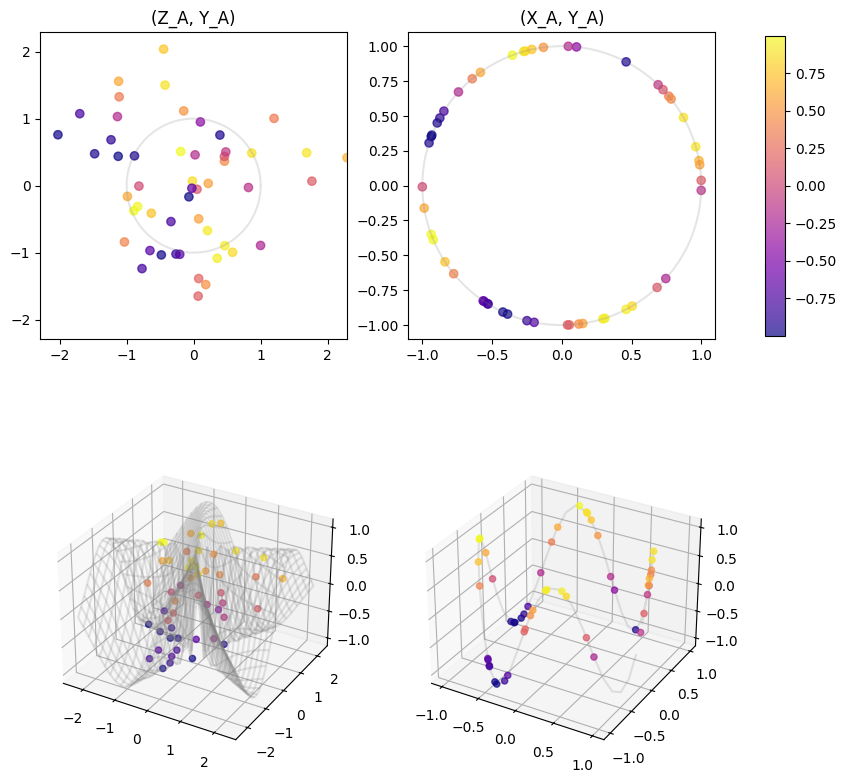

In [ ]:
# plot dataset X_A

fig = plt.figure(figsize=(10, 10))

theta = np.linspace(0, 2 * np.pi, 150)
x = np.cos(theta)
y = np.sin(theta)

ax0 = fig.add_subplot(2, 2, 2)
ax1 = fig.add_subplot(2, 2, 4, projection='3d')
ax2 = fig.add_subplot(2, 2, 1)
ax3 = fig.add_subplot(2, 2, 3, projection='3d')

scatter0 = ax0.scatter(normX_A[:, 0], normX_A[:, 1], c=Y_A, cmap='plasma', alpha = 0.7)
ax0.plot(x, y, alpha = 0.2, color = 'gray')

ax2.scatter(X_A[:, 0], X_A[:, 1], c=Y_A, cmap='plasma', alpha = 0.7)
ax2.plot(x, y, alpha = 0.2, color = 'gray')

ax1.scatter(normX_A[:, 0], normX_A[:, 1], Y_A, c=Y_A, cmap='plasma', alpha = 0.7)
ax1.plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)

ax3.scatter(X_A[:, 0], X_A[:, 1], Y_A, c=Y_A, cmap='plasma', alpha = 0.7)

r = torch.max(torch.abs(X_A))

grid_x = np.linspace(-r, r, 30)
grid_y = np.linspace(-r, r, 30)
X_grid, Y_grid = np.meshgrid(grid_x, grid_y)

angles_grid = np.arctan2(Y_grid, X_grid)

Z_grid = np.sin(4 * angles_grid)

ax3.plot_wireframe(X_grid, Y_grid, Z_grid, color='gray', alpha=0.2)

ax0.set_box_aspect(1)
ax2.set_xlim([-r, r])
ax2.set_ylim([-r, r])
ax2.set_box_aspect(1)
ax0.set_title('(X_A, Y_A)')
ax2.set_title('(Z_A, Y_A)')

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.555, 0.02, 0.3])
fig.colorbar(scatter0, cax=cbar_ax)

plt.show()

In [ ]:
m = [1, 10, 100, 1000, 10000, 100000]
eta = 1
epochs = 20000

In [ ]:
# plots for normalized dataset X_A and labels determined after

plotY_A = []

for i in range(len(m)):
  plotX_A = []

  print(f"Training on dataset X_A for m = {m[i]}")
  model = NeuralNetwork(d, m[i])
  optimizer = torch.optim.SGD([model.W, model.a], lr=eta)

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(normX_A)
    loss = 0.5 * torch.mean((U - Y_A) ** 2)

    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      plotY_A.append(loss.item())
      plotX_A.append(epoch+1)

    loss.backward()
    optimizer.step()

Training on dataset X_A for m = 1
Epoch 1 Loss: 0.5920433998
Epoch 2 Loss: 0.2930232584
Epoch 3 Loss: 0.2664425075
Epoch 4 Loss: 0.2561987638
Epoch 5 Loss: 0.2514411211
Epoch 6 Loss: 0.2490594387
Epoch 7 Loss: 0.2477815449
Epoch 8 Loss: 0.2470194548
Epoch 9 Loss: 0.2464886308
Epoch 10 Loss: 0.2460495979
Epoch 20 Loss: 0.237091735
Epoch 30 Loss: 0.2185113132
Epoch 40 Loss: 0.2176388353
Epoch 50 Loss: 0.2176365703
Epoch 60 Loss: 0.21762833
Epoch 70 Loss: 0.2176387459
Epoch 80 Loss: 0.2176325619
Epoch 90 Loss: 0.2176306993
Epoch 100 Loss: 0.2176400125
Epoch 200 Loss: 0.2176251262
Epoch 300 Loss: 0.2176386863
Epoch 400 Loss: 0.2176242024
Epoch 500 Loss: 0.2176357955
Epoch 600 Loss: 0.2176263779
Epoch 700 Loss: 0.2176355869
Epoch 800 Loss: 0.217624709
Epoch 900 Loss: 0.2176383585
Epoch 1000 Loss: 0.2176249027
Epoch 2000 Loss: 0.2176319957
Epoch 3000 Loss: 0.2176408619
Epoch 4000 Loss: 0.2176278681
Epoch 5000 Loss: 0.2176328301
Epoch 6000 Loss: 0.2176297307
Epoch 7000 Loss: 0.217625156
Epoch

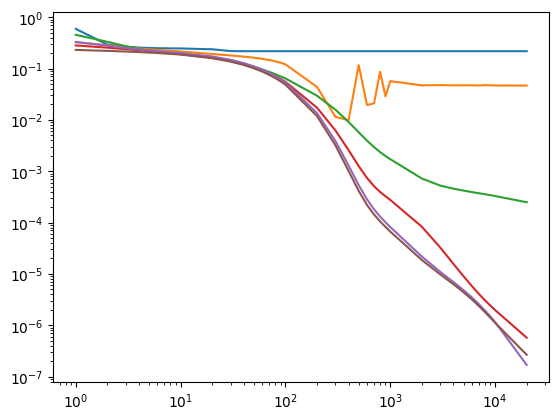

In [ ]:
for i in range(len(m)):
  plt.loglog(plotX_A, plotY_A[i*len(plotX_A):(i+1)*len(plotX_A)], label = f'm = {m[i]}')

plt.show()

In [ ]:
# plots for dataset X_A with not normalized inputs but same labels

plotY_Amod = []

for i in range(len(m)):
  plotX_Amod = []

  print(f"Training on dataset X_A for m = {m[i]}")
  model = NeuralNetwork(d, m[i])
  optimizer = torch.optim.SGD([model.W, model.a], lr=eta)

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(X_A)
    loss = 0.5 * torch.mean((U - Y_A) ** 2)

    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      plotY_Amod.append(loss.item())
      plotX_Amod.append(epoch+1)

    loss.backward()
    optimizer.step()

Training on dataset X_A for m = 1
Epoch 1 Loss: 0.5341533422
Epoch 2 Loss: 0.2340629846
Epoch 3 Loss: 0.2337301224
Epoch 4 Loss: 0.2334365696
Epoch 5 Loss: 0.2331753969
Epoch 6 Loss: 0.2330120504
Epoch 7 Loss: 0.2328635752
Epoch 8 Loss: 0.2327277809
Epoch 9 Loss: 0.2326034307
Epoch 10 Loss: 0.2325416803
Epoch 20 Loss: 0.2325079292
Epoch 30 Loss: 0.2325067669
Epoch 40 Loss: 0.2325062305
Epoch 50 Loss: 0.2325059474
Epoch 60 Loss: 0.232505843
Epoch 70 Loss: 0.2325057834
Epoch 80 Loss: 0.2325057536
Epoch 90 Loss: 0.2325057387
Epoch 100 Loss: 0.2325057387
Epoch 200 Loss: 0.2325057238
Epoch 300 Loss: 0.2325057387
Epoch 400 Loss: 0.2325057387
Epoch 500 Loss: 0.2325057387
Epoch 600 Loss: 0.2325057387
Epoch 700 Loss: 0.2325057387
Epoch 800 Loss: 0.2325057387
Epoch 900 Loss: 0.2325057387
Epoch 1000 Loss: 0.2325057387
Epoch 2000 Loss: 0.2325057387
Epoch 3000 Loss: 0.2325057387
Epoch 4000 Loss: 0.2325057387
Epoch 5000 Loss: 0.2325057387
Epoch 6000 Loss: 0.2325057387
Epoch 7000 Loss: 0.2325057387
E

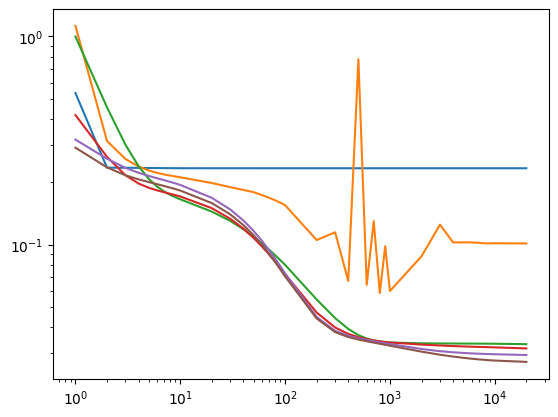

In [ ]:
for i in range(len(m)):
  plt.loglog(plotX_Amod, plotY_Amod[i*len(plotX_Amod):(i+1)*len(plotX_Amod)], label = f'm = {m[i]}')

plt.show()

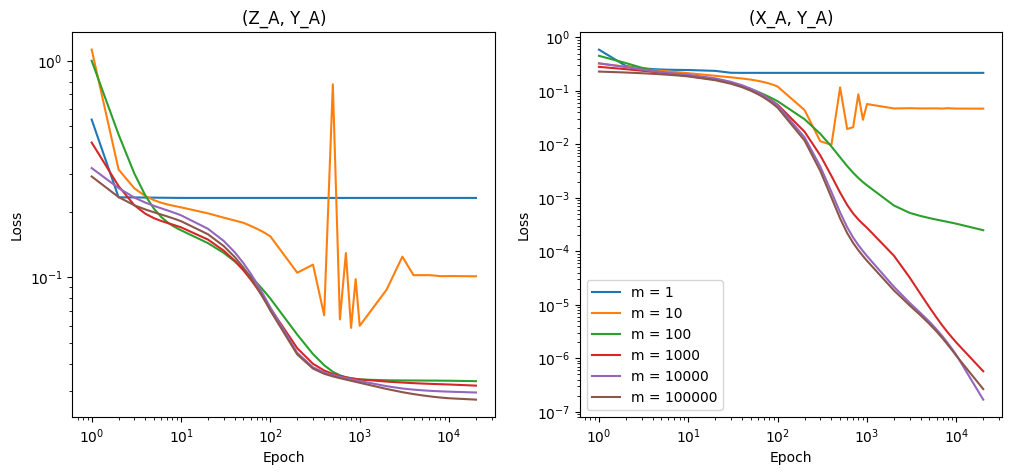

In [ ]:
fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1, 2, 1)
ax0 = fig.add_subplot(1, 2, 2)
for i in range(len(m)):
  ax0.loglog(plotX_A, plotY_A[i*len(plotX_A):(i+1)*len(plotX_A)], label = f'm = {m[i]}')
  ax1.loglog(plotX_Amod, plotY_Amod[i*len(plotX_Amod):(i+1)*len(plotX_Amod)], label = f'm = {m[i]}')

ax0.set_title('(X_A, Y_A)')
ax1.set_title('(Z_A, Y_A)')
ax0.set_xlabel('Epoch')
ax0.set_ylabel('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax0.legend()

plt.show()

In [ ]:
stop

NameError: name 'stop' is not defined

## Comparison for fixed and trainable output layer

In [ ]:
m = [1, 10, 100, 1000, 10000, 100000]
eta = 1
epochs = 20000

In [ ]:
# plots for dataset X_0

plotY_0fix = []

for i in range(len(m)):
  plotX_0fix = []

  print(f"Training on dataset X_0 for m = {m[i]}")
  model = NeuralNetwork(d, m[i])
  optimizer = torch.optim.SGD([model.W], lr=eta)

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(X_0)
    loss = 0.5 * torch.mean((U - Y_0) ** 2)

    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      plotY_0fix.append(loss.item())
      plotX_0fix.append(epoch+1)

    loss.backward()
    optimizer.step()

Training on dataset X_0 for m = 1
Epoch 1 Loss: 0.666249454
Epoch 2 Loss: 0.478602916
Epoch 3 Loss: 0.3743065
Epoch 4 Loss: 0.3171754777
Epoch 5 Loss: 0.2864542902
Epoch 6 Loss: 0.2699759007
Epoch 7 Loss: 0.2608389556
Epoch 8 Loss: 0.2556994259
Epoch 9 Loss: 0.2528083622
Epoch 10 Loss: 0.251196444
Epoch 20 Loss: 0.2516698241
Epoch 30 Loss: 0.2516005635
Epoch 40 Loss: 0.2515194416
Epoch 50 Loss: 0.2515160143
Epoch 60 Loss: 0.2513686121
Epoch 70 Loss: 0.2513202429
Epoch 80 Loss: 0.2516057491
Epoch 90 Loss: 0.2515212893
Epoch 100 Loss: 0.2514921725
Epoch 200 Loss: 0.2513686121
Epoch 300 Loss: 0.2513597608
Epoch 400 Loss: 0.2516086698
Epoch 500 Loss: 0.2516057491
Epoch 600 Loss: 0.2515202463
Epoch 700 Loss: 0.2515192926
Epoch 800 Loss: 0.2514921725
Epoch 900 Loss: 0.2513686121
Epoch 1000 Loss: 0.2513597608
Epoch 2000 Loss: 0.2515202463
Epoch 3000 Loss: 0.2513686121
Epoch 4000 Loss: 0.2516057491
Epoch 5000 Loss: 0.2514921725
Epoch 6000 Loss: 0.2516086698
Epoch 7000 Loss: 0.2515192926
Epoch 

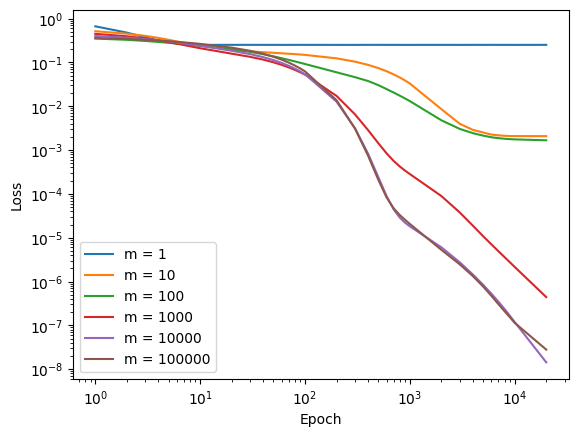

In [ ]:
for i in range(len(m)):
  plt.loglog(plotX_0fix, plotY_0fix[i*len(plotX_0fix):(i+1)*len(plotX_0fix)], label = f'm = {m[i]}')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# plots for dataset X_0

plotY_0 = []

for i in range(len(m)):
  plotX_0 = []

  print(f"Training on dataset X_0 for m = {m[i]}")
  model = NeuralNetwork(d, m[i])
  optimizer = torch.optim.SGD([model.W, model.a], lr=eta)

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(X_0)
    loss = 0.5 * torch.mean((U - Y_0) ** 2)

    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      plotY_0.append(loss.item())
      plotX_0.append(epoch+1)

    loss.backward()
    optimizer.step()

Training on dataset X_0 for m = 1
Epoch 1 Loss: 0.420627296
Epoch 2 Loss: 0.2971470356
Epoch 3 Loss: 0.2751120329
Epoch 4 Loss: 0.265673846
Epoch 5 Loss: 0.2603619397
Epoch 6 Loss: 0.2569412291
Epoch 7 Loss: 0.2545870245
Epoch 8 Loss: 0.2529294193
Epoch 9 Loss: 0.2517647147
Epoch 10 Loss: 0.2509314716
Epoch 20 Loss: 0.2491838634
Epoch 30 Loss: 0.2491125911
Epoch 40 Loss: 0.2490971088
Epoch 50 Loss: 0.2490929663
Epoch 60 Loss: 0.2490940094
Epoch 70 Loss: 0.2490938455
Epoch 80 Loss: 0.2490920275
Epoch 90 Loss: 0.2490936369
Epoch 100 Loss: 0.2490938753
Epoch 200 Loss: 0.2490916848
Epoch 300 Loss: 0.2490931153
Epoch 400 Loss: 0.2490944713
Epoch 500 Loss: 0.2490927428
Epoch 600 Loss: 0.2490922958
Epoch 700 Loss: 0.2490936965
Epoch 800 Loss: 0.249094069
Epoch 900 Loss: 0.2490916848
Epoch 1000 Loss: 0.2490929663
Epoch 2000 Loss: 0.2490920871
Epoch 3000 Loss: 0.249091953
Epoch 4000 Loss: 0.2490929365
Epoch 5000 Loss: 0.2490936667
Epoch 6000 Loss: 0.2490942776
Epoch 7000 Loss: 0.249094218
Epoch

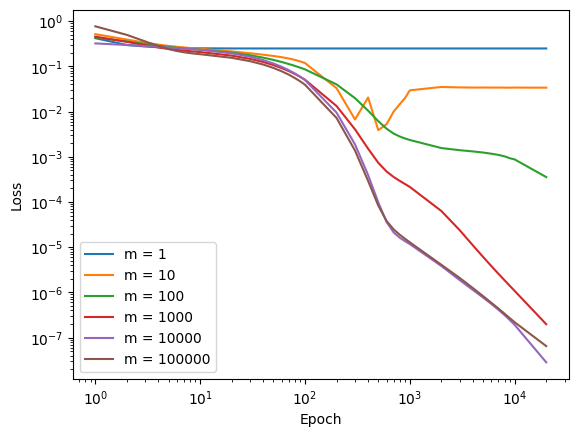

In [ ]:
for i in range(len(m)):
  plt.loglog(plotX_0, plotY_0[i*len(plotX_0):(i+1)*len(plotX_0)], label = f'm = {m[i]}')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

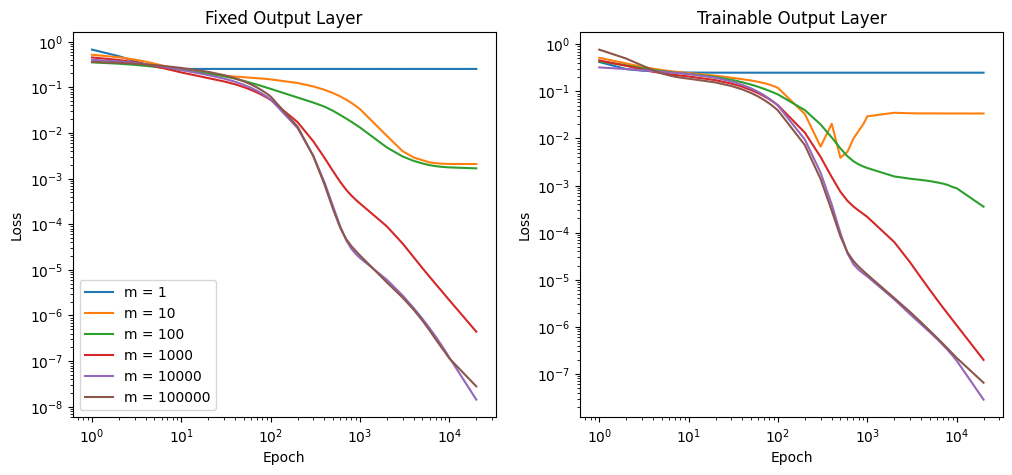

In [ ]:
fig = plt.figure(figsize=(12,5))
ax0 = fig.add_subplot(1, 2, 1)
ax1 = fig.add_subplot(1, 2, 2)

for i in range(len(m)):
  ax0.loglog(plotX_0fix, plotY_0fix[i*len(plotX_0fix):(i+1)*len(plotX_0fix)], label = f'm = {m[i]}')
  ax1.loglog(plotX_0, plotY_0[i*len(plotX_0):(i+1)*len(plotX_0)], label = f'm = {m[i]}')

ax0.set_xlabel('Epoch')
ax0.set_ylabel('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax0.set_title('Fixed Output Layer')
ax1.set_title('Trainable Output Layer')
ax0.legend()

plt.show()

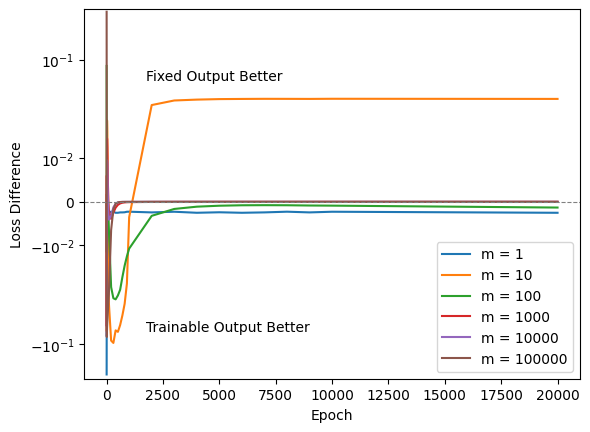

In [ ]:
for i in range(len(m)):
  plt.plot(plotX_0, torch.tensor(plotY_0[i*len(plotX_0):(i+1)*len(plotX_0)]) - torch.tensor(plotY_0fix[i*len(plotX_0fix):(i+1)*len(plotX_0fix)]), label = f'm = {m[i]}')

plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
plt.text(plt.xlim()[0] + plt.xlim()[1]*0.13, 0.05, 'Fixed Output Better', verticalalignment='bottom', horizontalalignment='left', color='black', fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
plt.text(plt.xlim()[0] + plt.xlim()[1]*0.13, -0.05, 'Trainable Output Better', verticalalignment='top', horizontalalignment='left', color='black', fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

plt.xlabel('Epoch')
plt.ylabel('Loss Difference')
plt.yscale('symlog', linthresh=0.02)
plt.legend()

plt.show()

## Comparison for increasing width



In [ ]:
m = [1, 10, 100, 1000, 10000, 100000]
eta = 1
epochs = 20000

In [ ]:
# grid_x = np.linspace(-1, 1, 50)
# grid_y = np.linspace(-1, 1, 50)
# X_grid, Y_grid = np.meshgrid(grid_x, grid_y)

# XY_grid = np.stack([X_grid.ravel(), Y_grid.ravel()], axis=1)
# XY_grid = torch.tensor(XY_grid, dtype=torch.float32)

In [ ]:
# plots for dataset X_0

plotY_0 = []
plotH_of_0 = []
plotH_diff = []

for i in range(len(m)):
  plotX_0 = []

  print(f"Training on dataset X_0 for m = {m[i]}")
  model = NeuralNetwork(d, m[i])
  optimizer = torch.optim.SGD([model.W, model.a], lr=eta)
  W_0 = model.W.detach().clone()
  a_0 = model.a.detach().clone()
  H_of_0 = gram_matrix_of_k(X_0, W_0, a_0, m[i])
  plotH_of_0.append(norm(H_of_0 - H_0))

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(X_0)
    loss = 0.5 * torch.mean((U - Y_0) ** 2)

    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      plotY_0.append(loss.item())
      plotX_0.append(epoch+1)

      H_of_k = gram_matrix_of_k(X_0, model.W, model.a, m[i])
      plotH_diff.append(norm(H_of_k - H_of_0).item())
      print('||H(k)-H(0)||', norm(H_of_k - H_of_0).item())

      '''if (epoch+1 == 20000): #(epoch == 0) | (epoch+1 == 100) | (epoch+1 == 1000) | (epoch+1 == 20000):
        W = model(XY_grid)

        fig = plt.figure(figsize=(12,10))

        ax = fig.add_subplot(121, projection='3d')
        ax.scatter(X_0[:, 0], X_0[:, 1], Y_0, color='red', alpha = 0.5)
        ax.scatter(X_0[:, 0], X_0[:, 1], U.detach().numpy(), color='blue', alpha = 0.5)
        ax.plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)

        ax2 = fig.add_subplot(1, 2, 2, projection='3d')
        ax2.scatter(X_0[:, 0], X_0[:, 1], Y_0, color='red', alpha = 0.5)
        ax2.plot_wireframe(X_grid, Y_grid, W.reshape(X_grid.shape).detach().numpy(), color='blue', alpha = 0.5)

        plt.show()'''

    loss.backward()
    optimizer.step()

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))

for i in range(len(m)):
  ax[0].loglog(plotX_0, plotY_0[i*len(plotX_0):(i+1)*len(plotX_0)], label = f'm = {m[i]}')
  ax[2].loglog(plotX_0[1::], plotH_diff[i*len(plotX_0)+1:(i+1)*len(plotX_0)], '-')
  ax[1].loglog(m[i], plotH_of_0[i], 'o')

ax[2].loglog(plotX_0, torch.full((len(plotX_0),), (lambda_0/4).item()), '--', label = 'theoretical bound', color = 'gray')
ax[1].loglog(m, torch.full((len(m),), (lambda_0/4).item()), '--', label = 'theoretical bound', color = 'gray')

ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('||H_0(k)-H_0(0)||')
ax[2].legend()

ax[1].set_xlabel('m')
ax[1].set_ylabel(r'||H_0(0) - H_0^\infty||')
ax[1].legend()

plt.show()

In [ ]:
# plots for dataset X_A

plotY_A = []
plotH_A_of_0 = []
plotH_A_diff = []

for i in range(len(m)):
  plotX_A = []

  print(f"Training on dataset X_A for m = {m[i]}")
  model = NeuralNetwork(d, m[i])
  optimizer = torch.optim.SGD([model.W, model.a], lr=eta)
  W_A = model.W.detach().clone()
  a_A = model.a.detach().clone()
  H_A_of_0 = gram_matrix_of_k(normX_A, W_A, a_A, m[i])
  plotH_A_of_0.append(norm(H_A_of_0 - H_A))

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(normX_A)
    loss = 0.5 * torch.mean((U - Y_A) ** 2)

    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      plotY_A.append(loss.item())
      plotX_A.append(epoch+1)

      H_A_of_k = gram_matrix_of_k(normX_A, model.W, model.a, m[i])
      plotH_A_diff.append(norm(H_A_of_k - H_A_of_0).item())
      print('||H_A(k)-H_A(0)||', norm(H_A_of_k - H_A_of_0).item())

      '''      if (epoch+1 == 20000):
        W = model(XY_grid)

        fig = plt.figure(figsize=(12,10))

        ax = fig.add_subplot(121, projection='3d')
        ax.scatter(normX_A[:, 0], normX_A[:, 1], Y_A, color='red', alpha = 0.5)
        ax.scatter(normX_A[:, 0], normX_A[:, 1], U.detach().numpy(), color='blue', alpha = 0.5)
        ax.plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)

        ax2 = fig.add_subplot(1, 2, 2, projection='3d')
        ax2.scatter(normX_A[:, 0], normX_A[:, 1], Y_A, color='red', alpha = 0.5)
        ax2.plot_wireframe(X_grid, Y_grid, W.reshape(X_grid.shape).detach().numpy(), color='blue', alpha = 0.5)

        plt.show()'''

    loss.backward()
    optimizer.step()

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))

for i in range(len(m)):
  ax[0].loglog(plotX_A, plotY_A[i*len(plotX_A):(i+1)*len(plotX_A)], label = f'm = {m[i]}')
  ax[2].loglog(plotX_A[1::], plotH_A_diff[i*len(plotX_A)+1:(i+1)*len(plotX_A)])
  ax[1].loglog(m[i], plotH_A_of_0[i], 'o')

ax[2].loglog(plotX_A, torch.full((len(plotX_A),), (lambda_A/4).item()), '--', label = 'theoretical bound', color = 'gray')
ax[1].loglog(m, torch.full((len(m),), (lambda_A/4).item()), '--', label = 'theoretical bound', color = 'gray')

ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('||H_A(k)-H_A(0)||')
ax[2].legend()

ax[1].set_xlabel('m')
ax[1].set_ylabel('||H_A(0) - H_A^\infty||')
ax[1].legend()

plt.show()

In [ ]:
# plots for dataset X_B

plotY_B = []
plotH_B_of_0 = []
plotH_B_diff = []

for i in range(len(m)):
  plotX_B = []

  print(f"Training on dataset X_B for m = {m[i]}")
  model = NeuralNetwork(d, m[i])
  optimizer = torch.optim.SGD([model.W, model.a], lr=eta)
  W_B = model.W.detach().clone()
  a_B = model.a.detach().clone()
  H_B_of_0 = gram_matrix_of_k(normX_B, W_B, a_B, m[i])
  plotH_B_of_0.append(norm(H_B_of_0 - H_B))

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(normX_B)
    loss = 0.5 * torch.mean((U - Y_B) ** 2)

    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      plotY_B.append(loss.item())
      plotX_B.append(epoch+1)

      H_B_of_k = gram_matrix_of_k(normX_B, model.W, model.a, m[i])
      plotH_B_diff.append(norm(H_B_of_k - H_B_of_0).item())
      print('||H_B(k)-H_B(0)||', norm(H_B_of_k - H_B_of_0).item())

      '''      if (epoch+1 == 20000):
        W = model(XY_grid)

        fig = plt.figure(figsize=(12,10))

        ax = fig.add_subplot(121, projection='3d')
        ax.scatter(normX_B[:, 0], normX_B[:, 1], Y_B, color='red', alpha = 0.5)
        ax.scatter(normX_B[:, 0], normX_B[:, 1], U.detach().numpy(), color='blue', alpha = 0.5)
        ax.plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)

        ax2 = fig.add_subplot(1, 2, 2, projection='3d')
        ax2.scatter(normX_B[:, 0], normX_B[:, 1], Y_B, color='red', alpha = 0.5)
        ax2.plot_wireframe(X_grid, Y_grid, W.reshape(X_grid.shape).detach().numpy(), color='blue', alpha = 0.5)

        plt.show()'''

    loss.backward()
    optimizer.step()

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))

for i in range(len(m)):
  ax[0].loglog(plotX_B, plotY_B[i*len(plotX_B):(i+1)*len(plotX_B)], label = f'm = {m[i]}')
  ax[2].loglog(plotX_B[1::], plotH_B_diff[i*len(plotX_B)+1:(i+1)*len(plotX_B)])
  ax[1].loglog(m[i], plotH_B_of_0[i], 'o')

#ax[0].loglog(plotX_B, (1 - (eta*lambda_B*0.5))**torch.tensor(plotX_B) * MAXplotY_B, '--', color = 'gray', label = 'error decay')
ax[2].loglog(plotX_B, torch.full((len(plotX_B),), (lambda_B/4).item()), '--', label = 'theoretical bound', color = 'gray')
ax[1].loglog(m, torch.full((len(m),), (lambda_B/4).item()), '--', label = 'theoretical bound', color = 'gray')

ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('||H_B(k)-H_B(0)||')
ax[2].legend()

ax[1].set_xlabel('m')
ax[1].set_ylabel('||H_B(0) - H_B^\infty||')
ax[1].legend()

plt.show()

In [ ]:
# plots for dataset X_C

plotY_C = []
plotH_C_of_0 = []
plotH_C_diff = []

for i in range(len(m)):
  plotX_C = []

  print(f"Training on dataset X_C for m = {m[i]}")
  model = NeuralNetwork(d, m[i])
  optimizer = torch.optim.SGD([model.W, model.a], lr=eta)
  W_C = model.W.detach().clone()
  a_C = model.a.detach().clone()
  H_C_of_0 = gram_matrix_of_k(normX_C, W_C, a_C, m[i])
  plotH_C_of_0.append(norm(H_C_of_0 - H_C))

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(normX_C)
    loss = 0.5 * torch.mean((U - Y_C) ** 2)

    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      plotY_C.append(loss.item())
      plotX_C.append(epoch+1)

      H_C_of_k = gram_matrix_of_k(normX_C, model.W, model.a, m[i])
      plotH_C_diff.append(norm(H_C_of_k - H_C_of_0).item())
      print('||H_C(k)-H_C(0)||', norm(H_C_of_k - H_C_of_0).item())

      '''      if (epoch+1 == 20000):
        W = model(XY_grid)

        fig = plt.figure(figsize=(12,10))

        ax = fig.add_subplot(121, projection='3d')
        ax.scatter(normX_C[:, 0], normX_C[:, 1], Y_C, color='red', alpha = 0.5)
        ax.scatter(normX_C[:, 0], normX_C[:, 1], U.detach().numpy(), color='blue', alpha = 0.5)
        ax.plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)

        ax2 = fig.add_subplot(1, 2, 2, projection='3d')
        ax2.scatter(normX_C[:, 0], normX_C[:, 1], Y_C, color='red', alpha = 0.5)
        ax2.plot_wireframe(X_grid, Y_grid, W.reshape(X_grid.shape).detach().numpy(), color='blue', alpha = 0.5)

        plt.show()'''

    loss.backward()
    optimizer.step()

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))

for i in range(len(m)):
  ax[0].loglog(plotX_C, plotY_C[i*len(plotX_C):(i+1)*len(plotX_C)], label = f'm = {m[i]}')
  ax[2].loglog(plotX_C[1::], plotH_C_diff[i*len(plotX_C)+1:(i+1)*len(plotX_C)])
  ax[1].loglog(m[i], plotH_C_of_0[i], 'o')

ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('||H_C(k)-H_C(0)||')
ax[2].legend()

ax[1].set_xlabel('m')
ax[1].set_ylabel('||H_C(0) - H_C^\infty||')
ax[1].legend()

plt.show()

In [ ]:
# plots for dataset X_D

plotY_D = []
plotH_D_of_0 = []
plotH_D_diff = []

for i in range(len(m)):
  plotX_D = []

  print(f"Training on dataset X_D for m = {m[i]}")
  model = NeuralNetwork(d, m[i])
  optimizer = torch.optim.SGD([model.W, model.a], lr=eta)
  W_D = model.W.detach().clone()
  a_D = model.a.detach().clone()
  H_D_of_0 = gram_matrix_of_k(normX_D, W_D, a_D, m[i])
  plotH_D_of_0.append(norm(H_D_of_0 - H_D))

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(normX_D)
    loss = 0.5 * torch.mean((U - Y_D) ** 2)

    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      plotY_D.append(loss.item())
      plotX_D.append(epoch+1)

      H_D_of_k = gram_matrix_of_k(normX_D, model.W, model.a, m[i])
      plotH_D_diff.append(norm(H_D_of_k - H_D_of_0).item())
      print('||H_D(k)-H_D(0)||', norm(H_D_of_k - H_D_of_0).item())

      '''if (epoch+1 == 20000):
        W = model(XY_grid)

        fig = plt.figure(figsize=(12,10))

        ax = fig.add_subplot(121, projection='3d')
        ax.scatter(normX_D[:, 0], normX_D[:, 1], Y_D, color='red', alpha = 0.5)
        ax.scatter(normX_D[:, 0], normX_D[:, 1], U.detach().numpy(), color='blue', alpha = 0.5)
        ax.plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)

        ax2 = fig.add_subplot(1, 2, 2, projection='3d')
        ax2.scatter(normX_D[:, 0], normX_D[:, 1], Y_D, color='red', alpha = 0.5)
        ax2.plot_wireframe(X_grid, Y_grid, W.reshape(X_grid.shape).detach().numpy(), color='blue', alpha = 0.5)

        plt.show()'''

    loss.backward()
    optimizer.step()

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))

for i in range(len(m)):
  ax[0].loglog(plotX_D, plotY_D[i*len(plotX_D):(i+1)*len(plotX_D)], label = f'm = {m[i]}')
  ax[2].loglog(plotX_D, plotH_D_diff[i*len(plotX_D):(i+1)*len(plotX_D)])
  ax[1].loglog(m[i], plotH_D_of_0[i], 'o')

#ax[1].loglog(plotX_D, torch.full((len(plotX_D),), (lambda_D/4).item()), '--', label = 'theoretical bound', color = 'gray')
#ax[2].loglog(m, torch.full((len(m),), (lambda_D/4).item()), '--', label = 'theoretical bound', color = 'gray')

ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('||H_D(k)-H_D(0)||')
ax[2].legend()

ax[1].set_xlabel('m')
ax[1].set_ylabel('||H_D(0) - H_D^\infty||')
ax[1].legend()

plt.show()

In [ ]:
# direct comparison

i = len(m) - 1

plt.loglog(plotX_0, plotY_0[i*len(plotX_0):(i+1)*len(plotX_0)], label = '(X_0, Y_0)', color = 'tab:blue')
#plt.loglog(plotX_0, (1 - (eta*lambda_0*0.5))**torch.tensor(plotX_0) * plotY_0[0], '--', color = 'blue')
plt.loglog(plotX_A, plotY_A[i*len(plotX_A):(i+1)*len(plotX_A)], label = '(X_A, Y_A)', color = 'tab:orange')
#plt.loglog(plotX_0, (1 - (eta*lambda_A*0.5))**torch.tensor(plotX_0) * plotY_A[0], '--', color = 'red')
plt.loglog(plotX_B, plotY_B[i*len(plotX_B):(i+1)*len(plotX_B)], label = '(X_B, Y_B)', color = 'tab:green')
plt.loglog(plotX_C, plotY_C[i*len(plotX_C):(i+1)*len(plotX_C)], label = '(X_C, Y_C)', color = 'tab:red')
plt.loglog(plotX_D, plotY_D[i*len(plotX_D):(i+1)*len(plotX_D)], label = '(X_D, Y_D)', color = 'tab:purple')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()